# A systematic comparison of the factors influencing forest height estimation from single-pass interferometric data, using inverse and machine-learning methods

**Anton Kostiukhin**<sup>1,2</sup>, **Tauri Tampuu**<sup>1</sup>, **Alexander Kmoch**<sup>2</sup>, **Jaan Praks**<sup>3</sup>, **Martin Jüssi**<sup>1</sup>

<sup>1</sup> Kappazeta Ltd., Kastani 42, Tartu 50410, Estonia  
<sup>2</sup> Landscape Geoinformatics Lab, Department of Geography, Institute of Ecology and Earth Sciences, University of Tartu, Vanemuise 46, Tartu 51003, Estonia  
<sup>3</sup> Department of Electronics and Nanoengineering, School of Electrical Engineering, Aalto University, Maarintie 8, Espoo 02150, Finland

---

## InSAR Height, Linear Regression model

In [1]:
import os
import re
import glob
import rasterio
import itertools
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from itertools import chain
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

Input path and information

In [ ]:
tdx_parent_path = "/tandem-x/batch_2024/{site}/1.6.2"

training_features_info_dict = {
    "HOA2HC": {
        "role": ["NAN"],            # Wether data layer is derived from master, slave, or interferogram
        "pol": ["VV", "VH"],        # Polarization
        "agg": ["mean", "median"],  # Function to aggregate in zonal statistics
        "human": "InSAR Height"     # Human-readable name
    },
}

validation_feature_key = "MAA_HAG_21K_22K_23K"

In [ ]:
tdx_products_list = []

for site in [
    "pikknurme_100", 
    "saaremaa_100"
]:
    products = glob.glob(
        os.path.join(tdx_parent_path.format(site=site), "*"), 
        recursive=True
    )
    tdx_products_list.extend(products)

print("Products found:", len(tdx_products_list))

Products found: 39


In [4]:
tdx_products_to_keep = {
    "HoA_35_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045033_20240805T045036", #	D	24.654	-36.022	    102.203	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045035_20240805T045041", #	D	24.67	-35.911	    102.203	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T050753_20240804T050758", #	D	22.135	33.351	    97.943	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T050757_20240804T050801", #	D	22.149	33.246	    97.943	TSX-1 +
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240815T050753_20240815T050758", #	D	23.429	35.138	    98.906	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240815T050757_20240815T050802", #	D	23.44	35.031	    98.906	TSX-1
    ],
    "HoA_35_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045033_20241226T045036", #	D	24.662	-35.73	    103.007	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045035_20241226T045041", #	D	24.679	-35.633	    103.007	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20241225T050758", #	D	22.181	32.684	    100.091	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050757_20241225T050802", #	D	22.195	32.593	    100.091	TSX-1 +
    ],
    "HoA_50_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044159_20240811T044206", #	D	35.863	50.881	    112.64	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044205_20240811T044208", #	D	35.866	50.772	    112.64	TSX-1
    ],
    "HoA_50_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044200_20241221T044207", #	D	35.894	-50.683	    113.082	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044206_20241221T044209", #	D	35.897	-50.591	    113.082	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241220T045921_20241220T045929", #	D	33.837	-47.566	    111.833	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241220T045926_20241220T045929", #	D	33.838	-47.489	    111.833	TDX-1
    ],
    "HoA_60_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043325_20240806T043328", #	D	44.944	64.983	    120.07	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043327_20240806T043334", #	D	44.952	64.882	    120.07	TSX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240816T045046_20240816T045051", #	D	44.133	64.12	    118.4	TSX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240816T045050_20240816T045055", #	D	44.139	64.022	    118.4	TSX-1
    ],
    "HoA_60_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044202_20241005T044209", #	D	35.888	-57.242	    100.157	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044208_20241005T044211", #	D	35.891	-57.146	    100.157	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241227T043325_20241227T043329", #	D	44.982	-63.713	    122.413	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241227T043328_20241227T043334", #	D	44.991	-63.628	    122.413	TDX-1
    ],
    # "HoA_250_LEAVES_ON": [
    #     # No products from summer time
    # ],
    "HoA_250_LEAVES_OFF": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155519_20241009T155524", #	A	40.655	-238.789	28.298	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155523_20241009T155527", #	A	40.65	-235.898	28.298	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155515_20241225T155521", #	A	40.679	-282.545	23.967	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155520_20241225T155524", #	A	40.674	-277.649	23.967	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241008T161227_20241008T161232", #	A	40.68	-256.363	26.453	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20241008T161231_20241008T161236", #	A	40.674	-252.958	26.453	TDX-1
    ],
    "HoA_370_LEAVES_ON": [
        # Pikknurme
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155515_20240804T155521", #	A	40.672	-372.034	18.24	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155520_20240804T155524", #	A	40.667	-363.571	18.24	TDX-1
        # Saaremaa
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20240803T161228", #	A	40.675	-401.384	16.984	TDX-1
        "TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20240803T161232", #	A	40.668	-391.554	16.984	TDX-1
    ],
    # "HoA_370_LEAVES_OFF": [
    #     # No products from summer time
    # ]
}

tdx_products_list = [x for x in tdx_products_list if any(k in x for k in list(chain.from_iterable(tdx_products_to_keep.values())))]

print("Products found:", len(tdx_products_list))

Products found: 34


Data readers

In [5]:
def read_product_metadata(df, tdx_path):
    """
    Read product metadata from dim files and write into corresponding dataframe.
    """
    dim_file = os.path.join(tdx_path, "*.dim")
    dim_file = glob.glob(dim_file, recursive=True)[0]

    tdm_tree = ET.parse(dim_file).getroot()
    
    orbit_direction = tdm_tree.find(".//MDElem[@name='CoSSC_Metadata']//MDATTR[@name='orbitDirection']").text
    incidence_angle = round(float(tdm_tree.find(".//MDElem[@name='CoSSC_Metadata']//MDElem[@name='sceneCenterCoord']//MDATTR[@name='incidenceAngle']").text), 3)
    hoa = round(float(tdm_tree.find(".//MDATTR[@name='heightOfAmbiguity']").text), 3)
    effective_baseline = round(float(tdm_tree.find(".//MDATTR[@name='effectiveBaseline']").text), 3)
    _id_master_sat = tdm_tree.find(".//MDATTR[@name='inSARmasterID']").text
    master_sat = tdm_tree.find(f".//MDATTR[@name='satelliteID{_id_master_sat.lower()}']").text

    df["md_name"] = os.path.basename(tdx_path)
    df["md_incidence_angle"] = incidence_angle
    df["md_hoa"] = abs(hoa)
    df["md_orbit"] = 0 if orbit_direction == "D" else 1
    df["md_master_satellite"] = 1 if master_sat == "TDX-1" else 0
    df["md_effective_baseline"] = effective_baseline

    # Regex to parse tdm name
    rx = r"TDM1_SAR__COS_BIST_SM_D_SRA_(?P<date>\d{8})T\d{6}_\d{8}T\d{6}"
    rx = re.compile(rx)

    _match = rx.search(tdx_path)
    if _match is None:
        raise ValueError()
    date = _match.group("date")

    df["md_date"] = date

    if "pikknurme_100" in dim_file:
        df["md_site"] = "Pikknurme"
    if "saaremaa_100" in dim_file:
        df["md_site"] = "Saaremaa"

    return df

In [6]:
def read_compartment_ids(df, tdx_path):
    """
    Read raster containing IDs of forest comparmtments.
    """
    raster_file = glob.glob(
        os.path.join(
            tdx_path, "**", "IV", "MTS_GEO_ERALDISID.tif"
        ),
        recursive=True
    )
    raster_file = raster_file.pop()

    with rasterio.open(raster_file) as src:
        arr = src.read(1)
        arr = arr.astype(np.float32)
        arr = np.where(arr == -32768.0, np.nan, arr)
        arr = arr.ravel()

        df["eraldis_id"] = arr

    return df

In [7]:
def read_chm(df, tdx_path):
    """
    Read raster containing validation forest height.
    """
    raster_file = glob.glob(
        os.path.join(
            tdx_path, "**", "IV", f"{validation_feature_key}.tif"
        ),
        recursive=True
    )
    raster_file = raster_file.pop()

    with rasterio.open(raster_file) as src:
        arr = src.read(1)
        arr = arr.astype(np.float32)
        arr = np.where(arr == -32768.0, np.nan, arr)
        arr = arr.ravel()

        df["chm"] = arr

    return df

In [8]:
def read_training_features(df, tdx_path):
    """
    Read SAR obervables used as training features in the modelling.
    """
    # Regex to parse names of TDM feature files
    rx = r"(?P<sat>TDX|TSX|TDM)_(?P<role>MST|SLV|NAN)_(\d{8}T\d{6}_\d{8}T\d{6})_(?P<key>[A-Za-z0-9]+)_(?P<pol>\w+).tif"
    rx = re.compile(rx)

    # Based on existing tif files pick those which are needed
    l3_feature_files = os.path.join(tdx_path, "**", "III", "*.tif")
    l3_feature_files = glob.glob(l3_feature_files, recursive=True)

    for l3_file in l3_feature_files:
        _match = rx.search(l3_file)
        if _match is None:
            continue
        role = _match.group("role")
        key = _match.group("key")
        pol = _match.group("pol")

        is_requested = training_features_info_dict.get(key, {})
        is_requested =  role in is_requested.get("role", []) and pol in is_requested.get("pol", [])
        if is_requested:
            with rasterio.open(l3_file) as src:
                arr = src.read(1)
                arr = arr.astype(np.float32)
                arr = np.where(arr == -32768.0, np.nan, arr)
                arr = arr.ravel()

                _column = "{}_{}_{}".format(role, key, pol).lower()
                df[_column] = arr

    return df

In [9]:
samples_all_df = []

for tdx_path in tdx_products_list:
    print(os.path.basename(tdx_path))

    # Read features
    df = pd.DataFrame()
    df = read_compartment_ids(df, tdx_path)
    df = read_product_metadata(df, tdx_path)
    df = read_chm(df, tdx_path)
    df = read_training_features(df, tdx_path)

    # Concat all samples
    df = df[df["eraldis_id"].notna()]
    df = df[df["chm"].notna()]

    samples_all_df.append(df)

samples_all_df = pd.concat(samples_all_df, ignore_index=True)

TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155515_20240804T155521
TDM1_SAR__COS_BIST_SM_D_SRA_20240804T155520_20240804T155524
TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045033_20240805T045036
TDM1_SAR__COS_BIST_SM_D_SRA_20240805T045035_20240805T045041
TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043325_20240806T043328
TDM1_SAR__COS_BIST_SM_D_SRA_20240806T043327_20240806T043334
TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044159_20240811T044206
TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044205_20240811T044208
TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044202_20241005T044209
TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044208_20241005T044211
TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155519_20241009T155524
TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155523_20241009T155527
TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044200_20241221T044207
TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044206_20241221T044209
TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155515_20241225T155521
TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155520_20241225T155524
TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045

In [10]:
# Sort and check contents
samples_all_df = samples_all_df.sort_values(by=["eraldis_id", "md_name"], ascending=[True, True])
samples_all_df.head(10)

,eraldis_id,md_name,md_incidence_angle,md_hoa,md_orbit,md_master_satellite,md_effective_baseline,md_date,md_site,chm,nan_hoa2hc_vv,nan_hoa2hc_vh
15994695,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,16.332607,16.404902,27.577700
15994734,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.720924,13.906308,12.272013
15994735,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.511700,18.577776,16.985731
15994775,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,19.391788,14.887515,17.330866
15994776,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.495867,15.094254,17.194750
15994777,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.109465,13.602020,15.500176
15994818,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.211636,13.799279,12.767344
15994819,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.789562,17.295654,17.276703
15994820,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.122274,14.763548,16.183722
15994821,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.720772,12.710437,8.636123


Remove compartments from overlapping areas between same-day products

In [11]:
# Find the earliest product per parcel_id and date
earliest_md = (
    samples_all_df.groupby(["eraldis_id", "md_date"])["md_name"]
    .min()
    .reset_index()
)
earliest_md.head(10)

,eraldis_id,md_date,md_name
0,100641.0,20240803,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...
1,100641.0,20240815,TDM1_SAR__COS_BIST_SM_D_SRA_20240815T050753_20...
2,100641.0,20240816,TDM1_SAR__COS_BIST_SM_D_SRA_20240816T045046_20...
3,100641.0,20241008,TDM1_SAR__COS_BIST_SM_D_SRA_20241008T161231_20...
4,748875.0,20240811,TDM1_SAR__COS_BIST_SM_D_SRA_20240811T044159_20...
5,748875.0,20241005,TDM1_SAR__COS_BIST_SM_D_SRA_20241005T044202_20...
6,748875.0,20241009,TDM1_SAR__COS_BIST_SM_D_SRA_20241009T155523_20...
7,748875.0,20241221,TDM1_SAR__COS_BIST_SM_D_SRA_20241221T044200_20...
8,748875.0,20241225,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T155520_20...
9,748875.0,20241226,TDM1_SAR__COS_BIST_SM_D_SRA_20241226T045033_20...


In [12]:
# Keep only rows matching the earliest product
samples_all_df = samples_all_df.merge(earliest_md, on=["eraldis_id", "md_date", "md_name"])
samples_all_df.head(10)

,eraldis_id,md_name,md_incidence_angle,md_hoa,md_orbit,md_master_satellite,md_effective_baseline,md_date,md_site,chm,nan_hoa2hc_vv,nan_hoa2hc_vh
0,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,16.332607,16.404902,27.577700
1,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.720924,13.906308,12.272013
2,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.511700,18.577776,16.985731
3,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,19.391788,14.887515,17.330866
4,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.495867,15.094254,17.194750
5,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.109465,13.602020,15.500176
6,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.211636,13.799279,12.767344
7,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.789562,17.295654,17.276703
8,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.122274,14.763548,16.183722
9,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.720772,12.710437,8.636123


Remove extreme and unreasonable values from height rasters

In [ ]:
columns_by = ["hoa2hc"]

for c in samples_all_df.columns:
    if any(key in c for key in columns_by):
        samples_all_df = samples_all_df[((samples_all_df[c] >= 0.0)) & (samples_all_df[c] <= 50.0)]

samples_all_df

,eraldis_id,md_name,md_incidence_angle,md_hoa,md_orbit,md_master_satellite,md_effective_baseline,md_date,md_site,chm,nan_hoa2hc_vv,nan_hoa2hc_vh
0,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,16.332607,16.404902,27.577700
1,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.720924,13.906308,12.272013
2,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,17.511700,18.577776,16.985731
3,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,19.391788,14.887515,17.330866
4,100641.0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161227_20...,40.668,391.554,1,1,16.984,20240803,Saaremaa,18.495867,15.094254,17.194750
...,...,...,...,...,...,...,...,...,...,...,...,...
17798972,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,17.870321,0.891420,3.636387
17798973,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,19.996056,1.274681,4.281916
17798974,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,20.715813,0.961157,3.323581
17798975,11848819.0,TDM1_SAR__COS_BIST_SM_D_SRA_20241225T050753_20...,22.181,32.684,0,0,100.091,20241225,Saaremaa,18.817926,0.878328,2.099392


Aggregate per product and comparment and calculate compartment based statistics

In [ ]:
agg_dict = {
    "md_site": ("md_site", "first"),
    "md_orbit": ("md_orbit", "first"),
    "md_incidence_angle": ("md_incidence_angle", "first"),
    "md_hoa": ("md_hoa", "first"),
    "md_master_satellite": ("md_master_satellite", "first"),
    "md_effective_baseline": ("md_effective_baseline", "first"),
    "md_date": ("md_date", "first"),

    "chm_mean": ("chm", "mean"),
    "chm_median": ("chm", "median"),
}

for base_name, params in training_features_info_dict.items():
    # Generate all combinations of role, pol, and agg
    for role, pol, agg in itertools.product(params["role"], params["pol"], params["agg"]):
        # Create column name
        inp_col_name = f"{role}_{base_name}_{pol}".lower()
        agg_col_name = f"{role}_{base_name}_{pol}_{agg}".lower()

        # Add to aggregation dict
        agg_dict[agg_col_name] = (inp_col_name, agg)

print("Generated aggregation dictionary:")
for key, value in agg_dict.items():
    print(f"{key}={value}")

Generated aggregation dictionary:
md_site=('md_site', 'first')
md_orbit=('md_orbit', 'first')
md_incidence_angle=('md_incidence_angle', 'first')
md_hoa=('md_hoa', 'first')
md_master_satellite=('md_master_satellite', 'first')
md_effective_baseline=('md_effective_baseline', 'first')
md_date=('md_date', 'first')
chm_mean=('chm', 'mean')
chm_median=('chm', 'median')
nan_hoa2hc_vv_mean=('nan_hoa2hc_vv', 'mean')
nan_hoa2hc_vv_median=('nan_hoa2hc_vv', 'median')
nan_hoa2hc_vh_mean=('nan_hoa2hc_vh', 'mean')
nan_hoa2hc_vh_median=('nan_hoa2hc_vh', 'median')


In [15]:
samples_agg_df = samples_all_df.groupby(["md_name", "eraldis_id"]).agg(**agg_dict).reset_index()
samples_agg_df.head(10)

,md_name,eraldis_id,md_site,md_orbit,md_incidence_angle,md_hoa,md_master_satellite,md_effective_baseline,md_date,chm_mean,chm_median,nan_hoa2hc_vv_mean,nan_hoa2hc_vv_median,nan_hoa2hc_vh_mean,nan_hoa2hc_vh_median
0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836089.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.364841,21.357933,13.852601,13.343676,14.831244,14.913046
1,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836113.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,22.550751,22.542267,16.170813,16.085411,14.768172,14.349102
2,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836123.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.746855,21.944107,14.185940,14.201933,14.445884,14.371146
3,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103561.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.547481,11.468403,5.020676,4.305384,7.728849,7.219542
4,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103569.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.531087,11.386520,10.717487,10.668285,8.112618,8.684717
5,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103575.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,12.968261,12.968458,5.987343,5.048051,6.339990,6.551004
6,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237159.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,17.340286,17.294298,9.454317,9.612736,9.234203,9.226233
7,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237187.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,13.338782,13.284115,5.573264,5.257948,5.202997,4.868743
8,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237201.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,16.370195,16.310423,9.588582,9.437651,7.399815,7.387811
9,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237209.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,15.523559,15.572256,9.355736,8.974324,7.795362,7.568255


Join with forest registry shapefile to bring info about tree species

In [16]:
mts_df = gpd.read_file("../metsaregister_bspm75.gpkg")

In [17]:
mts_df["l2_height_weighted"] = mts_df["l2_height_weighted"].fillna(0.0)

In [18]:
samples_agg_df = samples_agg_df.merge(
    mts_df,
    how="left",
    left_on="eraldis_id",
    right_on="eraldis_id"
)
samples_agg_df.head(10)

,md_name,eraldis_id,md_site,md_orbit,md_incidence_angle,md_hoa,md_master_satellite,md_effective_baseline,md_date,chm_mean,...,ownership_code,l1_dominant,l1_height_weighted,l1_tree_count,l2_dominant,l2_height_weighted,l1_l2_mix,prod_overlap_count,compactness,geometry
0,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836089.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.364841,...,R,Pine,18.0,455.0,NaN,0.0,Pine,7,0.680328,"MULTIPOLYGON (((390813.465 6458148.766, 390811..."
1,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836113.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,22.550751,...,R,Other Coniferous,23.4,518.0,NaN,0.0,Other Coniferous,7,0.597390,"MULTIPOLYGON (((390771.042 6458296.755, 390780..."
2,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,836123.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,21.746855,...,R,Pine,21.0,452.0,NaN,0.0,Pine,7,0.639148,"MULTIPOLYGON (((390782.861 6458411.712, 390844..."
3,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103561.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.547481,...,R,Pine,8.3,1457.0,NaN,0.0,Pine,5,0.667451,"MULTIPOLYGON (((398635.348 6458480.653, 398668..."
4,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103569.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,11.531087,...,R,Other Deciduous,14.0,1123.0,NaN,0.0,Other Deciduous,6,0.713149,"MULTIPOLYGON (((398132.258 6457810.292, 398149..."
5,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1103575.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,12.968261,...,R,Birch,8.0,1441.0,NaN,0.0,Birch,6,0.412017,"MULTIPOLYGON (((398440.061 6458321.608, 398455..."
6,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237159.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,17.340286,...,R,Other Deciduous,19.0,306.0,NaN,0.0,Other Deciduous,7,0.365106,"MULTIPOLYGON (((390868.038 6460465.918, 390888..."
7,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237187.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,13.338782,...,R,"Mixed, Majorly Deciduous",17.2,523.0,NaN,0.0,"Mixed, Majorly Deciduous",7,0.676944,"MULTIPOLYGON (((390587.662 6460369.72, 390623...."
8,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237201.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,16.370195,...,R,"Mixed, Majorly Deciduous",18.7,514.0,NaN,0.0,"Mixed, Majorly Deciduous",7,0.566860,"MULTIPOLYGON (((390663.891 6460128.28, 390709...."
9,TDM1_SAR__COS_BIST_SM_D_SRA_20240803T161223_20...,1237209.0,Saaremaa,1,40.675,401.384,1,16.984,20240803,15.523559,...,R,"Mixed, Majorly Deciduous",18.0,515.0,NaN,0.0,"Mixed, Majorly Deciduous",7,0.496920,"MULTIPOLYGON (((390940.153 6459911.083, 390915..."


Modelling

In [19]:
def fit_and_evaluate(samples_g_df, tree_type, chm_col, sph_col):
    """
    Fit Linear model and compute inversion metrics for a given tree type.
    """
    samples_t_df = samples_g_df[samples_g_df["l1_l2_mix"] == tree_type].copy()

    coeffs = np.polyfit(samples_t_df[sph_col], samples_t_df[chm_col], 1)
    p2 = np.poly1d(coeffs)

    # How many samples were used for fitting
    fit_count = len(samples_t_df)

    samples_t_df["inv_poly2d"] = p2(samples_t_df[sph_col])

    # Remove unreasonable results
    samples_t_df = samples_t_df.dropna(subset=[chm_col, "inv_poly2d"])
    samples_t_df = samples_t_df[(0.0 <= samples_t_df["inv_poly2d"]) & (samples_t_df["inv_poly2d"] <= 35.0)]

    # How many samples were inverted
    inv_count = len(samples_t_df)

    # Save results
    metrics = {
        "coeffs": coeffs,
        "fit_count": fit_count,
        "inv_count": inv_count,
        "r2": r2_score(samples_t_df[chm_col], samples_t_df["inv_poly2d"]),
        "mae": round(mean_absolute_error(samples_t_df[chm_col], samples_t_df["inv_poly2d"]), 2),
        "rmse": round(root_mean_squared_error(samples_t_df[chm_col], samples_t_df["inv_poly2d"]), 2),
        "bias": round(np.mean(samples_t_df["inv_poly2d"] - samples_t_df[chm_col]), 2),
    }

    return samples_t_df, metrics

In [20]:
chm_col = "chm_mean"
hoa_col = "nan_hoa_00_mean"
sph_cols = ["nan_hoa2hc_vh_mean", "nan_hoa2hc_vv_mean"]

tree_types = ["Birch", "Pine", "Spruce", "Mixed"]

fits = {}

for sph_col in sph_cols:
    for g_name, p_list in tdx_products_to_keep.items():
        samples_g_df = samples_agg_df[samples_agg_df["md_name"].isin(p_list)]

        for tree_type in tree_types:
            samples_t_df, metrics = fit_and_evaluate(
                samples_g_df, tree_type, chm_col, sph_col
            )
            fits[(g_name, sph_col, tree_type)] = (samples_t_df, metrics)

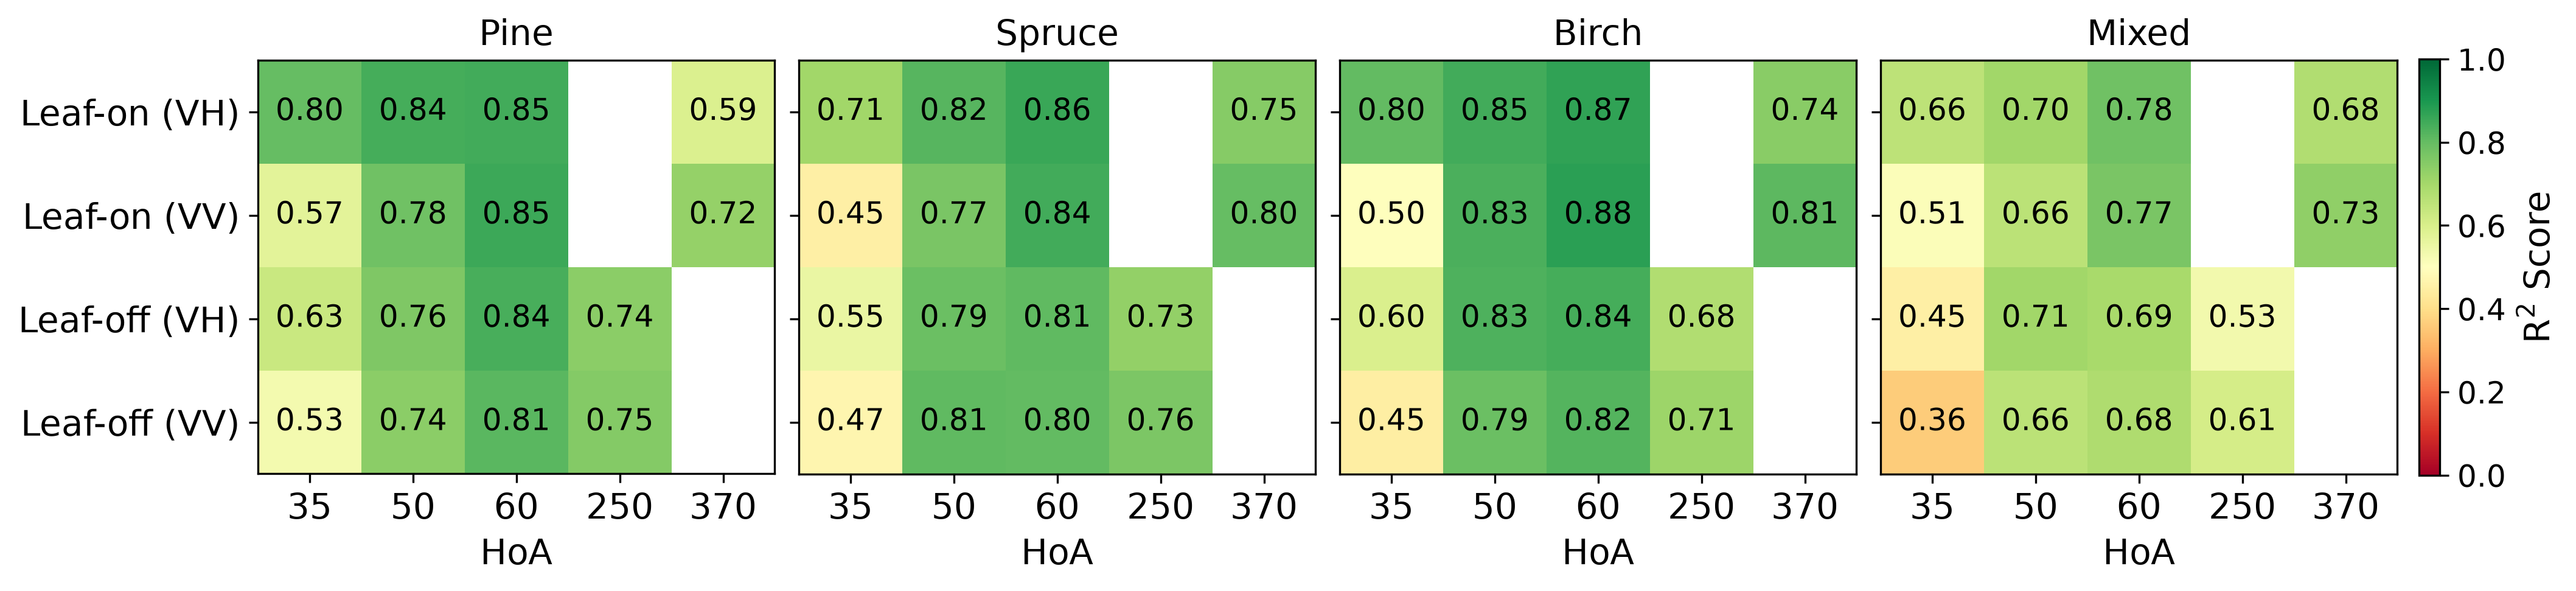

In [21]:
def plot_r2_heatmap(fits):
    tree_types = ["Pine", "Spruce", "Birch", "Mixed"]
    
    g_names = {g_name for (g_name, _, __) in fits.keys()}
    hoa_vals = sorted({g_name.split("_")[1] for g_name in g_names}, key=float)
    season_vals = ["Leaf-on", "Leaf-off"]
    pol_vals = sorted({coh_col.split("_")[2] for (_, coh_col, __) in fits.keys()})

    row_keys = [(l, p) for l in season_vals for p in pol_vals]

    # Build lookup: (tree_type, g_leaves, pol, g_hoa) -> r2
    grouped = {}
    for (g_name, coh_col, tree_type), (_, metrics) in fits.items():
        key = (
            tree_type,
            "Leaf-on" if "_ON" in g_name else "Leaf-off",
            coh_col.split("_")[2],
            g_name.split("_")[1],
        )
        grouped.setdefault(key, []).append(metrics["r2"])
    grouped = {k: np.mean(v) for k, v in grouped.items()}

    fig, axes = plt.subplots(
        1,
        len(tree_types),
        figsize=(3.5 * len(tree_types), 3.7),
        dpi=300,
        sharey=True,
        constrained_layout=True,
    )

    im = None
    for ax, tree in zip(axes, tree_types):
        matrix = np.full((len(row_keys), len(hoa_vals)), np.nan)
        for i, (leaves, pol) in enumerate(row_keys):
            for j, hoa in enumerate(hoa_vals):
                key = (tree, leaves, pol, hoa)
                if key in grouped:
                    matrix[i, j] = grouped[key]

        im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1)

        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                v = matrix[i, j]
                if not np.isnan(v):
                    color = "black" if 0.25 < v else "white"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=12, color=color)

        ax.set_title(str(tree), fontsize=14)
        ax.set_xticks(range(len(hoa_vals)))
        ax.set_xticklabels(hoa_vals, fontsize=14)
        ax.set_xlabel("HoA", fontsize=14)
        ax.set_xticks(np.arange(-0.5, len(hoa_vals), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(row_keys), 1), minor=True)
        ax.tick_params(which="minor", bottom=False, left=False)

    axes[0].set_yticks(range(len(row_keys)))
    axes[0].set_yticklabels([f"{l} ({p.upper()})" for l, p in row_keys], fontsize=14)

    cbar = fig.colorbar(im, ax=axes, label=r"$\text{R}^2$ Score", shrink=0.63, pad=0.01)
    cbar.set_label(r"$\text{R}^2$ Score", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    return fig

fig = plot_r2_heatmap(fits)